In [2]:
import pandas as pd
import numpy as np

# Load all 4 files
orders    = pd.read_csv(r'C:\Users\thakr\Downloads\olist_orders_dataset.csv')
items     = pd.read_csv(r'C:\Users\thakr\Downloads\olist_order_items_dataset.csv')
customers = pd.read_csv(r'C:\Users\thakr\Downloads\olist_customers_dataset.csv')
payments  = pd.read_csv(r'C:\Users\thakr\Downloads\olist_order_payments_dataset.csv')

print("Orders:", orders.shape)
print("Items:", items.shape)
print("Customers:", customers.shape)
print("Payments:", payments.shape)

Orders: (99441, 8)
Items: (112650, 7)
Customers: (99441, 5)
Payments: (103886, 5)


In [3]:
print(orders.head(3))
print("\n")
print(orders.dtypes)

                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00           2018-08-07 15:27:45   
2          2018-08-08 13:50:00           2018-08-17 18:06:29   

  order_estimated_delivery_date  
0           2017-10-18 00:00:00  
1           2018-08-13 00:00:00  
2           2018-09-04 00:00:00  


order_id                         object
customer_id    

In [4]:
for name, df in [('Orders', orders), ('Items', items), 
                 ('Customers', customers), ('Payments', payments)]:
    print(f"\n--- {name} ---")
    null_pct = (df.isnull().sum() / len(df) * 100).round(2)
    print(null_pct[null_pct > 0])


--- Orders ---
order_approved_at                0.16
order_delivered_carrier_date     1.79
order_delivered_customer_date    2.98
dtype: float64

--- Items ---
Series([], dtype: float64)

--- Customers ---
Series([], dtype: float64)

--- Payments ---
Series([], dtype: float64)


In [5]:
date_cols = ['order_purchase_timestamp',
             'order_approved_at',
             'order_delivered_customer_date',
             'order_estimated_delivery_date']

for col in date_cols:
    orders[col] = pd.to_datetime(orders[col])

# Extract useful features
orders['order_year']    = orders['order_purchase_timestamp'].dt.year
orders['order_month']   = orders['order_purchase_timestamp'].dt.month
orders['order_day']     = orders['order_purchase_timestamp'].dt.day_name()
orders['order_quarter'] = orders['order_purchase_timestamp'].dt.quarter
orders['delivery_days'] = (
    orders['order_delivered_customer_date'] -
    orders['order_purchase_timestamp']
).dt.days

print("Dates fixed!")
print(orders[['order_purchase_timestamp','order_year',
              'order_month','order_day','delivery_days']].head(3))

Dates fixed!
  order_purchase_timestamp  order_year  order_month  order_day  delivery_days
0      2017-10-02 10:56:33        2017           10     Monday            8.0
1      2018-07-24 20:41:37        2018            7    Tuesday           13.0
2      2018-08-08 08:38:49        2018            8  Wednesday            9.0


In [6]:
orders_delivered = orders[orders['order_status'] == 'delivered'].copy()

print(f"Total orders:     {len(orders)}")
print(f"Delivered orders: {len(orders_delivered)}")
print(f"Dropped:          {len(orders) - len(orders_delivered)}")

Total orders:     99441
Delivered orders: 96478
Dropped:          2963


In [7]:
master = orders_delivered \
    .merge(items, on='order_id', how='left') \
    .merge(customers, on='customer_id', how='left') \
    .merge(payments, on='order_id', how='left')

master = master.drop_duplicates(subset=['order_id', 'order_item_id'])

master = master.rename(columns={
    'payment_value': 'revenue',
    'customer_city': 'city',
    'customer_state': 'state'
})

print("Master table ready!")
print("Shape:", master.shape)
print(master[['order_id','revenue','city',
              'state','order_month','delivery_days']].head(3))

Master table ready!
Shape: (110197, 27)
                           order_id  revenue        city state  order_month  \
0  e481f51cbdc54678b7cc49136f2d6af7    18.12   sao paulo    SP           10   
3  53cdb2fc8bc7dce0b6741e2150273451   141.46   barreiras    BA            7   
4  47770eb9100c2d0c44946d9cf07ec65d   179.12  vianopolis    GO            8   

   delivery_days  
0            8.0  
3           13.0  
4            9.0  


In [8]:
master.to_csv('olist_master_cleaned.csv', index=False)
print("File saved as olist_master_cleaned.csv")

File saved as olist_master_cleaned.csv


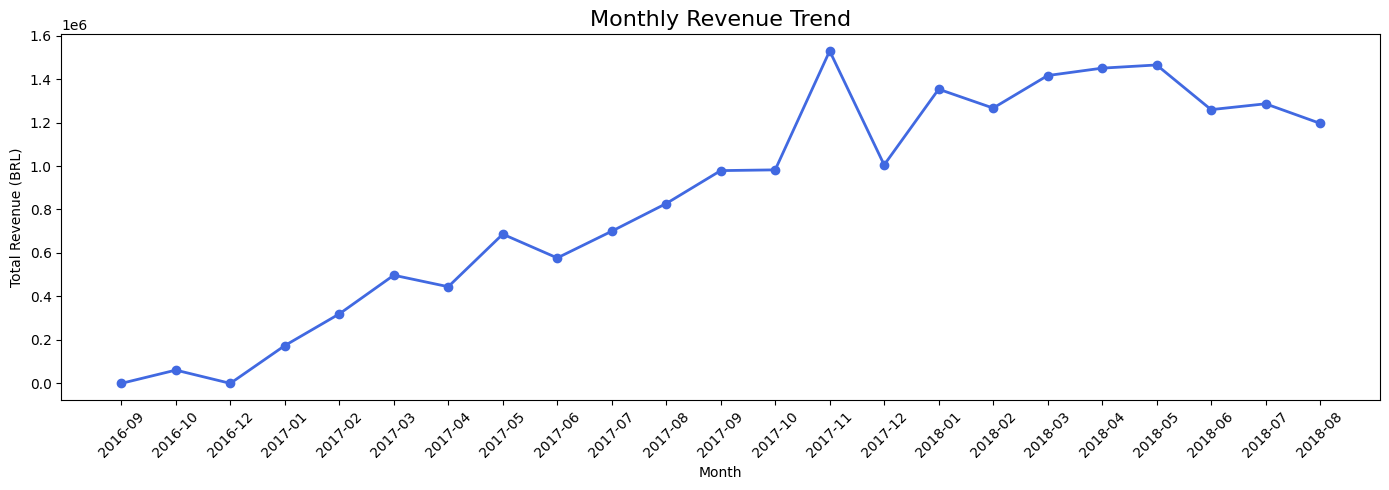

Done!


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

monthly = master.groupby(['order_year','order_month'])['revenue'].sum().reset_index()
monthly['period'] = monthly['order_year'].astype(str) + '-' + monthly['order_month'].astype(str).str.zfill(2)

plt.figure(figsize=(14,5))
plt.plot(monthly['period'], monthly['revenue'], marker='o', color='royalblue', linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend', fontsize=16)
plt.xlabel('Month')
plt.ylabel('Total Revenue (BRL)')
plt.tight_layout()
plt.savefig('monthly_trend.png', dpi=150)
plt.show()
print("Done!")

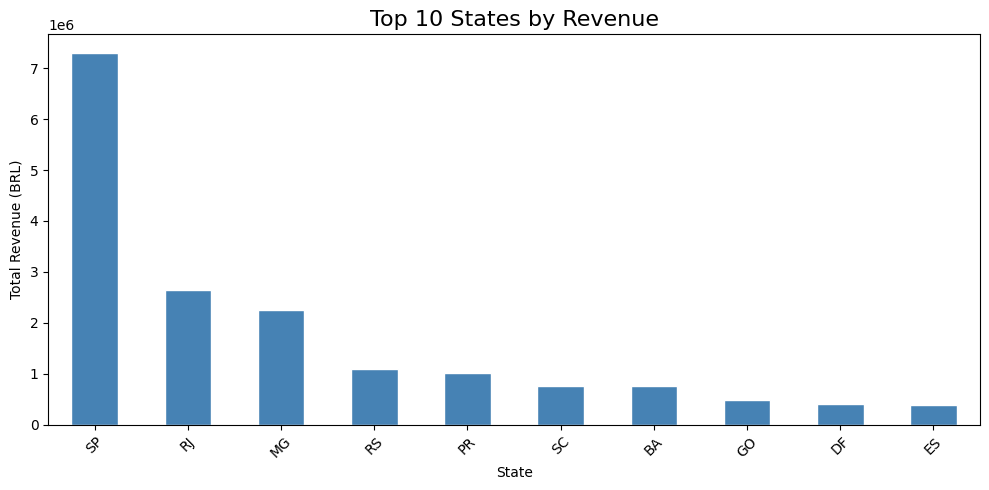

Done!


In [10]:
top_states = master.groupby('state')['revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
top_states.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Top 10 States by Revenue', fontsize=16)
plt.xlabel('State')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_states.png', dpi=150)
plt.show()
print("Done!")

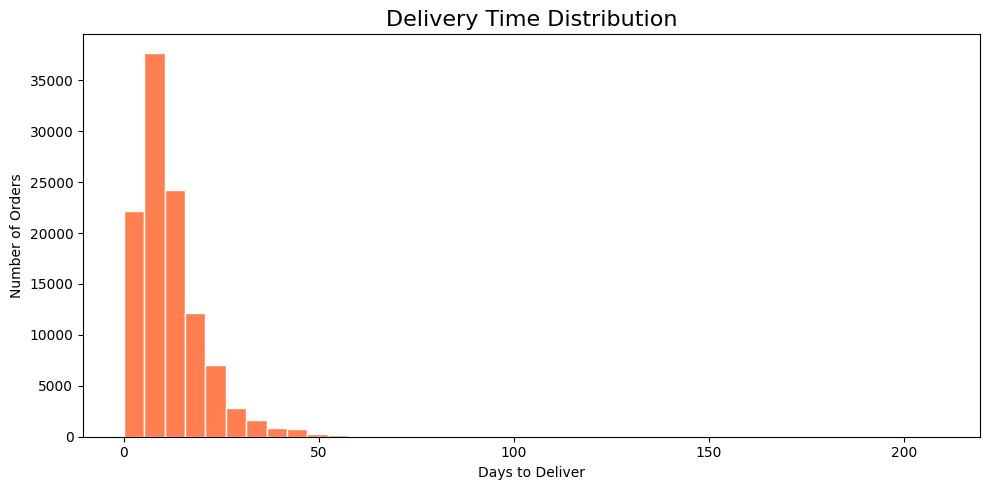

Average delivery days: 12.0
Fastest delivery: 0.0 days
Slowest delivery: 209.0 days


In [11]:
plt.figure(figsize=(10,5))
master['delivery_days'].dropna().plot(kind='hist', bins=40, color='coral', edgecolor='white')
plt.title('Delivery Time Distribution', fontsize=16)
plt.xlabel('Days to Deliver')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('delivery_dist.png', dpi=150)
plt.show()

print("Average delivery days:", round(master['delivery_days'].mean(), 1))
print("Fastest delivery:", master['delivery_days'].min(), "days")
print("Slowest delivery:", master['delivery_days'].max(), "days")

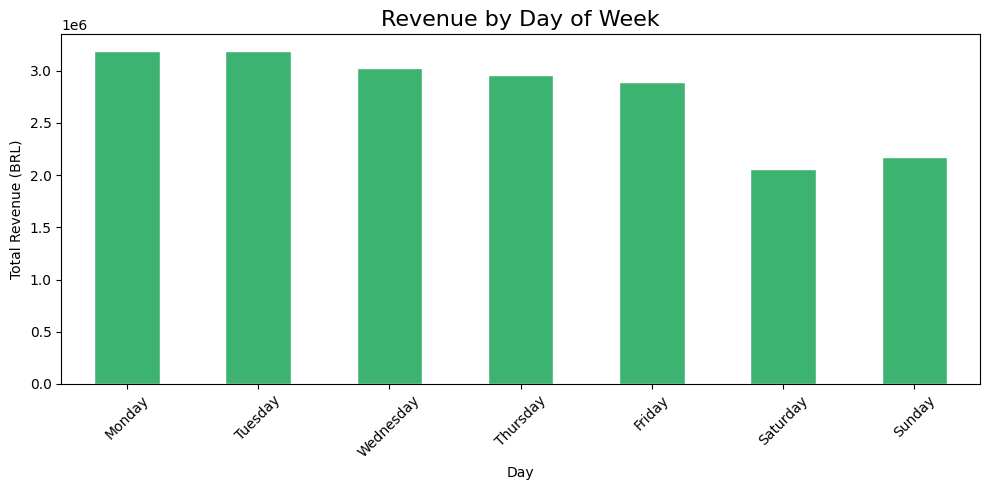

Done!


In [12]:
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

day_rev = master.groupby('order_day')['revenue'].sum().reindex(day_order)

plt.figure(figsize=(10,5))
day_rev.plot(kind='bar', color='mediumseagreen', edgecolor='white')
plt.title('Revenue by Day of Week', fontsize=16)
plt.xlabel('Day')
plt.ylabel('Total Revenue (BRL)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('day_revenue.png', dpi=150)
plt.show()
print("Done!")

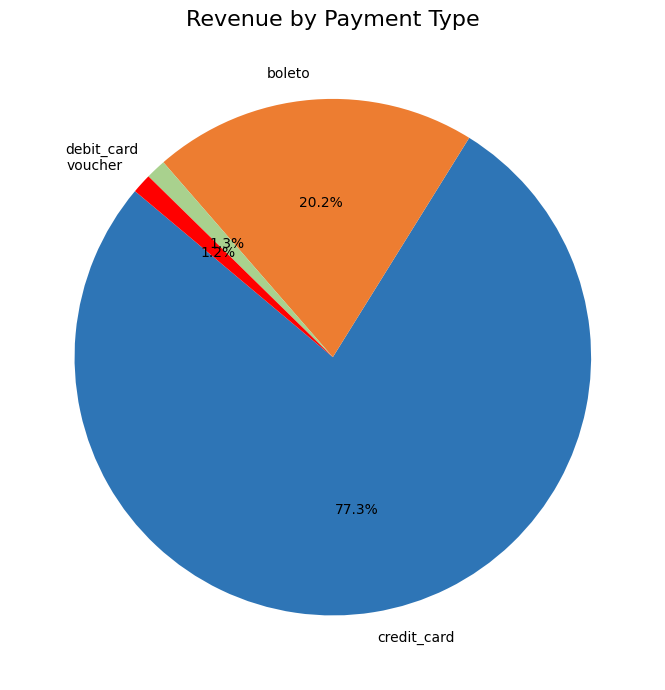

Done!


In [13]:
pay_type = master.groupby('payment_type')['revenue'].sum().sort_values(ascending=False)

plt.figure(figsize=(7,7))
pay_type.plot(kind='pie', autopct='%1.1f%%', startangle=140,
              colors=['#2E75B6','#ED7D31','#A9D18E','#FF0000'])
plt.title('Revenue by Payment Type', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.savefig('payment_type.png', dpi=150)
plt.show()
print("Done!")

In [14]:
import sqlite3
import pandas as pd

# Load cleaned file
master = pd.read_csv('olist_master_cleaned.csv')

# Create SQL database
conn = sqlite3.connect('ecommerce.db')
master.to_sql('orders', conn, if_exists='replace', index=False)

print("Database created!")
print("Total rows loaded:", pd.read_sql("SELECT COUNT(*) FROM orders", conn).values[0][0])

Database created!
Total rows loaded: 110197


In [15]:
q1 = pd.read_sql("""
    SELECT order_year, order_month,
           COUNT(DISTINCT order_id) AS total_orders,
           ROUND(SUM(revenue), 2) AS total_revenue
    FROM orders
    GROUP BY order_year, order_month
    ORDER BY order_year, order_month
""", conn)

print(q1)
q1.to_csv('sql_monthly_revenue.csv', index=False)
print("Saved!")

    order_year  order_month  total_orders  total_revenue
0         2016            9             1            NaN
1         2016           10           265       61016.06
2         2016           12             1          19.62
3         2017            1           750      173787.37
4         2017            2          1653      319541.76
5         2017            3          2546      497573.94
6         2017            4          2303      444680.99
7         2017            5          3546      686455.34
8         2017            6          3135      577077.32
9         2017            7          3872      699989.07
10        2017            8          4193      827331.67
11        2017            9          4150      978874.89
12        2017           10          4478      982301.67
13        2017           11          7289     1529374.41
14        2017           12          5513     1005110.68
15        2018            1          7069     1353432.56
16        2018            2    

In [16]:
q2 = pd.read_sql("""
    SELECT state,
           COUNT(DISTINCT order_id) AS total_orders,
           ROUND(SUM(revenue), 2) AS total_revenue,
           ROUND(AVG(revenue), 2) AS avg_order_value
    FROM orders
    GROUP BY state
    ORDER BY total_revenue DESC
    LIMIT 10
""", conn)

print(q2)
q2.to_csv('sql_top_states.csv', index=False)
print("Saved!")

  state  total_orders  total_revenue  avg_order_value
0    SP         40501     7297990.24           157.13
1    RJ         12350     2646234.50           187.11
2    MG         11354     2248490.91           174.09
3    RS          5345     1092662.18           178.13
4    PR          4923     1018415.18           180.28
5    SC          3546      758817.94           185.21
6    BA          3256      758340.73           205.90
7    GO          1957      486942.98           213.85
8    DF          2080      414275.41           175.91
9    ES          1995      393104.23           176.68
Saved!


In [17]:
q3 = pd.read_sql("""
    SELECT payment_type,
           COUNT(DISTINCT order_id) AS total_orders,
           ROUND(SUM(revenue), 2) AS total_revenue,
           ROUND(AVG(revenue), 2) AS avg_payment
    FROM orders
    GROUP BY payment_type
    ORDER BY total_revenue DESC
""", conn)

print(q3)
q3.to_csv('sql_payment_type.csv', index=False)
print("Saved!")

  payment_type  total_orders  total_revenue  avg_payment
0  credit_card         73220    15047174.11       180.53
1       boleto         19191     3943080.78       176.33
2   debit_card          1484      246657.51       149.31
3      voucher          2582      239659.94        84.72
4         None             1            NaN          NaN
Saved!


In [18]:
q4 = pd.read_sql("""
    SELECT state,
           ROUND(AVG(delivery_days), 1) AS avg_delivery_days,
           MIN(delivery_days) AS fastest,
           MAX(delivery_days) AS slowest,
           COUNT(DISTINCT order_id) AS total_orders
    FROM orders
    WHERE delivery_days IS NOT NULL
    GROUP BY state
    ORDER BY avg_delivery_days ASC
    LIMIT 10
""", conn)

print(q4)
q4.to_csv('sql_delivery.csv', index=False)
print("Saved!")

  state  avg_delivery_days  fastest  slowest  total_orders
0    SP                8.3      0.0    191.0         40494
1    MG               11.5      1.0    187.0         11354
2    PR               11.5      1.0     97.0          4923
3    DF               12.5      1.0     68.0          2080
4    SC               14.5      1.0     98.0          3546
5    RJ               14.7      0.0    208.0         12350
6    RS               14.7      1.0    186.0          5344
7    GO               14.9      1.0    181.0          1957
8    MS               15.1      3.0     58.0           701
9    ES               15.2      2.0    209.0          1995
Saved!


In [19]:
q5 = pd.read_sql("""
    SELECT order_day,
           COUNT(DISTINCT order_id) AS total_orders,
           ROUND(SUM(revenue), 2) AS total_revenue
    FROM orders
    GROUP BY order_day
    ORDER BY total_revenue DESC
""", conn)

print(q5)
q5.to_csv('sql_day_revenue.csv', index=False)
print("Saved!")

   order_day  total_orders  total_revenue
0    Tuesday         15503     3189280.17
1     Monday         15701     3185073.08
2  Wednesday         15076     3022348.27
3   Thursday         14323     2957504.80
4     Friday         13685     2895266.75
5     Sunday         11635     2170359.35
6   Saturday         10555     2056739.92
Saved!


In [21]:
q6 = pd.read_sql("""
    SELECT customer_id,
           city,
           state,
           COUNT(DISTINCT order_id) AS total_orders,
           ROUND(SUM(revenue), 2) AS total_spent
    FROM orders
    GROUP BY customer_id
    ORDER BY total_spent DESC
    LIMIT 20
""", conn)

print(q6)
q6.to_csv('sql_top_customers.csv', index=False)
print("Saved!")

                         customer_id                   city state  \
0   1617b1357756262bfa56ab541c47bc16         rio de janeiro    RJ   
1   bd5d39761aa56689a265d95d8d32b8be                goiania    GO   
2   be1b70680b9f9694d8c70f41fa3dc92b              sao paulo    SP   
3   05455dfa7cd02f13d132aa7a6a9729c6            divinopolis    MG   
4   1ff773612ab8934db89fd5afa8afe506         rio de janeiro    RJ   
5   ec5b2ba62e574342386871631fafd3fc             vila velha    ES   
6   e7d6802668de6e74d0d6c56565bf2a24              sao paulo    SP   
7   8c20d9bfbc96c5d39025d77a3ba83d7f          cicero dantas    BA   
8   f7622098214b4634b7fe7eee269b5426  campo novo do parecis    MT   
9   71901689c5f3e5adc27b1dd16b33f0b8               sao luis    MA   
10  cb87122c4871e202777cf243fbea2d12                guapore    RS   
11  10de381f8a8d23fff822753305f71cae       uniao da vitoria    PR   
12  91f92cfee46b79581b05aa974dd57ce5               curitiba    PR   
13  4a60b2ce1ee8c7b828e4bbcca5b86b